# Notebook 1: Data Quality and Dataset Understanding

Project: How Consistently Do Cells Respond to the Same Genetic Perturbation?

The purpose of this notebook is to establish, from
the actual file, what this dataset contains: its dimensions, its metadata fields, how
perturbations are labeled, what the expression matrix contains, and which parts of the
metadata are still uncertain and need to be checked against the original publication before
we rely on them in later notebooks.

Dataset: `AdamsonWeissman2016_GSM2406675_10X001.h5ad`, from the scPerturb harmonized
collection (Peidli et al. 2022), derived from Adamson, Norman, Jost et al. 2016 (Cell). This
file corresponds to a K562 pilot experiment within that study (non-essential transcription
factors and cell-cycle regulators), not the paper's main unfolded-protein-response screen.

Source: https://zenodo.org/record/10044268/files/AdamsonWeissman2016_GSM2406675_10X001.h5ad?download=1


## Setup

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Loading the dataset

In [2]:
data_path = "F:/scRNA/AdamsonWeissman2016_GSM2406675_10X001.h5ad"
adata = sc.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 5768 × 35635
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts'
    var: 'ensembl_id', 'ncounts', 'ncells'

## Basic dimensions

In [3]:
print("cells (n_obs):", adata.n_obs)
print("genes (n_vars):", adata.n_vars)
print("shape:", adata.shape)

cells (n_obs): 5768
genes (n_vars): 35635
shape: (5768, 35635)


## Cell metadata (`adata.obs`)

In [4]:
adata.obs.dtypes

perturbation         category
read count            float64
UMI count             float64
tissue_type          category
cell_line            category
cancer                   bool
disease              category
perturbation_type    category
celltype             category
organism             category
ncounts               float32
ngenes                  int64
percent_mito          float32
percent_ribo          float32
nperts                  int64
dtype: object

In [5]:
adata.obs.head()

,perturbation,read count,UMI count,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,ncounts,ngenes,percent_mito,percent_ribo,nperts
cell_barcode,,,,,,,,,,,,,,,
AAACATACACCGAT,CREB1_pDS269,1286.0,98.0,cell_line,K562,True,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,8138.0,2412,0.0,34.037846,2
AAACATACAGAGAT,SNAI1_pDS266,296.0,19.0,cell_line,K562,True,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,8980.0,2386,0.0,40.011135,2
AAACATACCAGAAA,62(mod)_pBA581,1829.0,162.0,cell_line,K562,True,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,28610.0,4404,0.0,40.003494,2
AAACATACGTTGAC,EP300_pDS268,1580.0,98.0,cell_line,K562,True,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,11346.0,2815,0.0,35.184204,2
AAACATACTGTTCT,62(mod)_pBA581,748.0,51.0,cell_line,K562,True,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,9864.0,2584,0.0,35.817112,2


### Missing values in obs

In [6]:
adata.obs.isna().sum()

perturbation         10
read count           10
UMI count            10
tissue_type           0
cell_line             0
cancer                0
disease               0
perturbation_type     0
celltype              0
organism              0
ncounts               0
ngenes                0
percent_mito          0
percent_ribo          0
nperts                0
dtype: int64

## Gene metadata (`adata.var`)

In [7]:
adata.var.dtypes

ensembl_id     object
ncounts       float32
ncells          int64
dtype: object

In [8]:
adata.var.head()

,ensembl_id,ncounts,ncells
gene_symbol,,,
MIR1302-10,ENSG00000243485,0.0,0
FAM138A,ENSG00000237613,0.0,0
OR4F5,ENSG00000186092,0.0,0
RP11-34P13.7,ENSG00000238009,0.0,0
RP11-34P13.8,ENSG00000239945,1.0,1


## Duplicate or problematic labels

In [9]:
n_duplicated_cells = adata.obs.index.duplicated().sum()
n_duplicated_genes = adata.var.index.duplicated().sum()
print("duplicated cell barcodes:", n_duplicated_cells)
print("duplicated gene symbols:", n_duplicated_genes)

duplicated cell barcodes: 0
duplicated gene symbols: 0


## Perturbation labels

`perturbation` is the column that identifies which guide each cell received.

In [10]:
perturbation_counts = adata.obs["perturbation"].value_counts(dropna=False)
perturbation_counts

perturbation
62(mod)_pBA581    1769
SPI1_pDS255        696
EP300_pDS268       632
SNAI1_pDS266       562
ZNF326_pDS262      557
BHLHE40_pDS258     553
CREB1_pDS269       506
DDIT3_pDS263       477
NaN                 10
*                    6
Name: count, dtype: int64

## Control candidate and ambiguous cells

In [11]:
control_label = "62(mod)_pBA581"

is_missing = adata.obs["perturbation"].isna()
is_ambiguous_mark = adata.obs["perturbation"] == "*"
is_ambiguous = is_missing | is_ambiguous_mark
is_control = adata.obs["perturbation"] == control_label
is_target = (~is_ambiguous) & (~is_control)

print("control candidate cells:", is_control.sum())
print("target perturbation cells:", is_target.sum())
print("ambiguous cells (NaN or '*'):", is_ambiguous.sum())
print("total:", is_control.sum() + is_target.sum() + is_ambiguous.sum(), "vs n_obs:", adata.n_obs)

control candidate cells: 1769
target perturbation cells: 3983
ambiguous cells (NaN or '*'): 16
total: 5768 vs n_obs: 5768


## Cells per perturbation

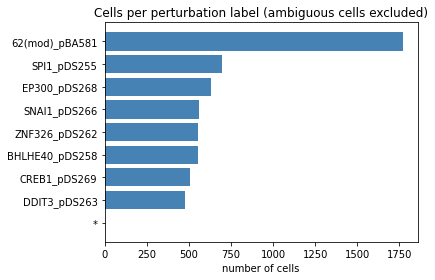

In [12]:
clean_counts = adata.obs.loc[~is_ambiguous, "perturbation"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(clean_counts.index.astype(str), clean_counts.values, color="steelblue")
ax.set_xlabel("number of cells")
ax.set_title("Cells per perturbation label (ambiguous cells excluded)")
plt.tight_layout()
plt.show()

## The `nperts` column

`nperts` is present in `obs` but its exact meaning is not documented anywhere we've looked
yet. The cross-tabulation below shows how it relates to `perturbation`.

In [13]:
pd.crosstab(adata.obs["perturbation"], adata.obs["nperts"], dropna=False)

nperts,0,1,2
perturbation,,,
NaN,10,0,0
62(mod)_pBA581,0,0,1769
*,0,6,0
BHLHE40_pDS258,0,0,553
CREB1_pDS269,0,0,506
DDIT3_pDS263,0,0,477
EP300_pDS268,0,0,632
SNAI1_pDS266,0,0,562
SPI1_pDS255,0,0,696


## Expression matrix: raw counts or already processed?

This matters directly for Notebook 2: normalizing a matrix that has already been normalized
would distort the data. There is no `.raw` and no `.layers` in this file, so whatever `X`
contains is the only expression data available.

In [14]:
X = adata.X
print("matrix type:", type(X))
print("dtype:", X.dtype)

nonzero_values = X.data
print("non-zero entries:", nonzero_values.size)
print("min non-zero value:", nonzero_values.min())
print("max non-zero value:", nonzero_values.max())
print("mean non-zero value:", nonzero_values.mean())

fraction_integer = np.mean(nonzero_values == np.round(nonzero_values))
print("fraction of non-zero values that are integer-valued:", fraction_integer)

matrix type: <class 'scipy.sparse._csc.csc_matrix'>
dtype: float32
non-zero entries: 14751450
min non-zero value: 1.0
max non-zero value: 564.0
mean non-zero value: 3.975087
fraction of non-zero values that are integer-valued: 1.0


In [15]:
row_sums = np.asarray(X.sum(axis=1)).flatten()
nonzero_genes_per_cell = np.asarray((X > 0).sum(axis=1)).flatten()

ncounts_diff = np.abs(row_sums - adata.obs["ncounts"].values)
ngenes_diff = np.abs(nonzero_genes_per_cell - adata.obs["ngenes"].values)

print("max difference between X row sums and obs['ncounts']:", ncounts_diff.max())
print("max difference between non-zero genes per cell and obs['ngenes']:", ngenes_diff.max())

max difference between X row sums and obs['ncounts']: 0.0
max difference between non-zero genes per cell and obs['ngenes']: 0


## Per-cell QC metrics already present in the file

In [16]:
adata.obs[["ncounts", "ngenes", "percent_mito", "percent_ribo"]].describe()

,ncounts,ngenes,percent_mito,percent_ribo
count,5768.000000,5768.000000,5768.0,5768.000000
mean,10166.141602,2557.463592,0.0,35.917324
std,3239.350098,462.586304,0.0,3.421465
min,1975.000000,520.000000,0.0,15.314178
25%,8255.750000,2332.000000,0.0,34.131576
50%,9969.000000,2580.000000,0.0,36.193380
75%,11942.750000,2831.000000,0.0,38.031264
max,28610.000000,4404.000000,0.0,65.062675


## Visual overview of QC properties

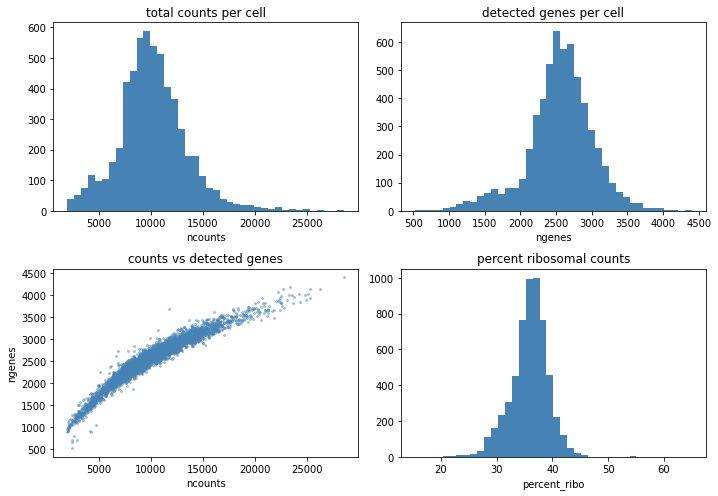

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].hist(adata.obs["ncounts"], bins=40, color="steelblue")
axes[0, 0].set_title("total counts per cell")
axes[0, 0].set_xlabel("ncounts")

axes[0, 1].hist(adata.obs["ngenes"], bins=40, color="steelblue")
axes[0, 1].set_title("detected genes per cell")
axes[0, 1].set_xlabel("ngenes")

axes[1, 0].scatter(adata.obs["ncounts"], adata.obs["ngenes"], s=4, alpha=0.4, color="steelblue")
axes[1, 0].set_xlabel("ncounts")
axes[1, 0].set_ylabel("ngenes")
axes[1, 0].set_title("counts vs detected genes")

axes[1, 1].hist(adata.obs["percent_ribo"], bins=40, color="steelblue")
axes[1, 1].set_title("percent ribosomal counts")
axes[1, 1].set_xlabel("percent_ribo")

plt.tight_layout()
plt.show()

## Sparsity of the expression matrix

In [18]:
sparsity = 1 - (X.nnz / (adata.n_obs * adata.n_vars))
print(f"fraction of zero entries in X: {sparsity:.4f}")

fraction of zero entries in X: 0.9282
